# Step 11 — Compare momentum, sentiment, and combined models

All approaches use the same November 22, 2024 cutoff, chronological training period, five-day safety gap, and unseen test dates.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "aapl_momentum_sentiment.csv"
PREDICTIONS_PATH = PROJECT_ROOT / "data" / "processed" / "model_comparison_predictions.csv"
CUTOFF_DATE = pd.Timestamp("2024-11-22")
data = pd.read_csv(DATA_PATH, parse_dates=["date"], index_col="date").sort_index()
data = data.loc[data.index <= CUTOFF_DATE].copy()
assert data[["aapl_momentum_5d", "average_sentiment_5d", "headline_count_5d"]].notna().all().all()

In [2]:
test_size = int(len(data) * 0.25)
gap_size = 5
test_start = len(data) - test_size
train = data.iloc[: test_start - gap_size].copy()
safety_gap = data.iloc[test_start - gap_size : test_start].copy()
test = data.iloc[test_start:].copy()

pd.DataFrame({
    "Rows": [len(train), len(safety_gap), len(test)],
    "Start": [train.index.min(), safety_gap.index.min(), test.index.min()],
    "End": [train.index.max(), safety_gap.index.max(), test.index.max()],
}, index=["Training", "Safety gap", "Testing"])

,Rows,Start,End
Training,349,2023-01-10,2024-05-30
Safety gap,5,2024-05-31,2024-06-06
Testing,118,2024-06-07,2024-11-22


## Model inputs

- **Momentum only:** previous five-day AAPL return.
- **Sentiment only:** five-day average FinBERT score and five-day headline count.
- **Combined:** all three features.

Standardization and logistic-regression fitting use training data only.

In [3]:
feature_sets = {
    "Momentum only": ["aapl_momentum_5d"],
    "Sentiment only": ["average_sentiment_5d", "headline_count_5d"],
    "Combined": ["aapl_momentum_5d", "average_sentiment_5d", "headline_count_5d"],
}
target = "outperformed"
y_train = train[target].astype(int)
y_test = test[target].astype(int)
models = {}
predictions = pd.DataFrame(index=test.index)
predictions["actual"] = y_test

for name, features in feature_sets.items():
    model = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
    model.fit(train[features], y_train)
    models[name] = model
    predictions[f"{name}_prediction"] = model.predict(test[features])
    predictions[f"{name}_probability"] = model.predict_proba(test[features])[:, 1]

majority_class = int(y_train.mode().iloc[0])
predictions["Majority baseline_prediction"] = majority_class
predictions["Majority baseline_probability"] = y_train.mean()

## Test-period results

ROC AUC evaluates probability ranking. A value of 0.5 is neutral; values below 0.5 rank outcomes in the wrong direction more often than the right direction.

In [4]:
results = {}
for name in ["Majority baseline", *feature_sets.keys()]:
    predicted = predictions[f"{name}_prediction"]
    probability = predictions[f"{name}_probability"]
    results[name] = {
        "Accuracy": accuracy_score(y_test, predicted),
        "Precision": precision_score(y_test, predicted, zero_division=0),
        "Recall": recall_score(y_test, predicted, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probability),
        "Predicted outperformances": int(predicted.sum()),
    }
results = pd.DataFrame(results).T
results.round(3)

,Accuracy,Precision,Recall,ROC AUC,Predicted outperformances
Majority baseline,0.500,0.500,1.000,0.500,118.0
Momentum only,0.525,0.514,0.915,0.503,105.0
Sentiment only,0.636,0.643,0.610,0.618,56.0
Combined,0.534,0.534,0.525,0.556,58.0


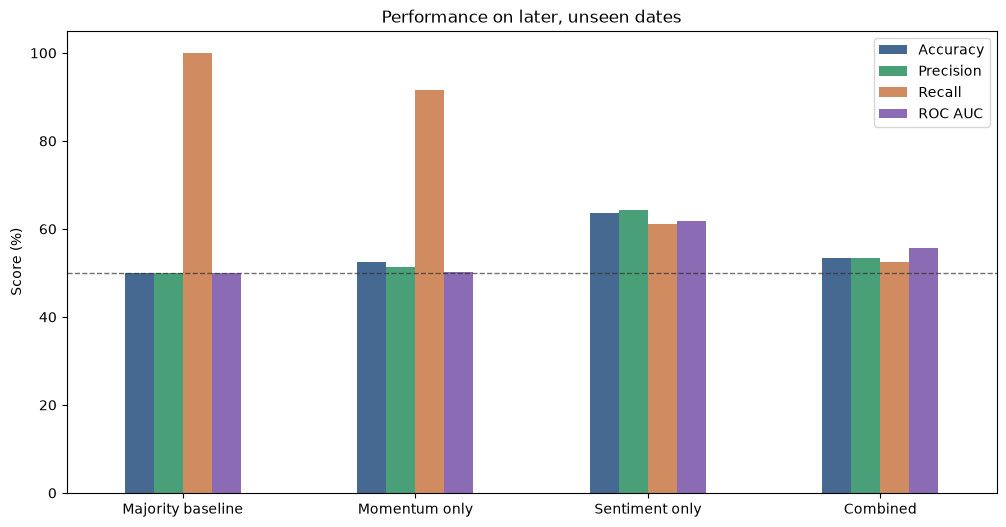

In [5]:
ax = (results[["Accuracy", "Precision", "Recall", "ROC AUC"]] * 100).plot.bar(
    figsize=(12, 6), rot=0, color=["#456990", "#49a078", "#d08c60", "#8b6bb3"]
)
ax.axhline(50, color="#333333", linestyle="--", linewidth=1, alpha=0.7)
ax.set_ylim(0, 105)
ax.set_ylabel("Score (%)")
ax.set_title("Performance on later, unseen dates")
ax.set_xlabel("")
plt.show()

## Learned directions

Because inputs were standardized, coefficient signs show whether higher feature values increased or decreased the model's estimated outperformance probability during training. They do not prove causation.

In [6]:
coefficient_rows = []
for name, features in feature_sets.items():
    coefficients = models[name].named_steps["logisticregression"].coef_[0]
    coefficient_rows.extend(
        {"Model": name, "Feature": feature, "Standardized coefficient": coefficient}
        for feature, coefficient in zip(features, coefficients)
    )
pd.DataFrame(coefficient_rows).round(3)

,Model,Feature,Standardized coefficient
0,Momentum only,aapl_momentum_5d,-0.079
1,Sentiment only,average_sentiment_5d,-0.076
2,Sentiment only,headline_count_5d,0.095
3,Combined,aapl_momentum_5d,-0.061
4,Combined,average_sentiment_5d,-0.061
5,Combined,headline_count_5d,0.095


In [7]:
predictions.to_csv(PREDICTIONS_PATH)
print(f"Saved {len(predictions)} test-date predictions to {PREDICTIONS_PATH}")

Saved 118 test-date predictions to /Users/keishakalra/Desktop/Financial_App/data/processed/model_comparison_predictions.csv


## Limitations

This is one stock, one period, and one fixed split. Neighboring five-day targets overlap, so observations are not independent. Model selection has not been tuned on a separate validation period, and the comparison does not include transaction costs.